# Homework 4
SIR model
 Problem 1 prompt:
 Consider a closed system with population of N=10,000 individuals. at time t=0 a single infection individual enters an otherwise fully suseptible population: S(0) = 9,999, I(0)=1, R(0)=0. The disease speads according to the SIR model with transmission rate $\beta$ = 3X10(-5) and recovery rate $\gamma$ 0.1 day^-1

In [7]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [8]:
# Population size and given SIR parameters
N = 10000
beta = 3e-5
gamma = 0.1

def sir_model(t, y, beta, gamma):
    S, I, R = y
    dS = -beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I
    return [dS, dI, dR]

# Initial conditions from the prompt: S(0)=9999, I(0)=1, R(0)=0
y0 = [9999, 1, 0]
t_span = (0, 120)
t_eval = np.linspace(*t_span, 500)

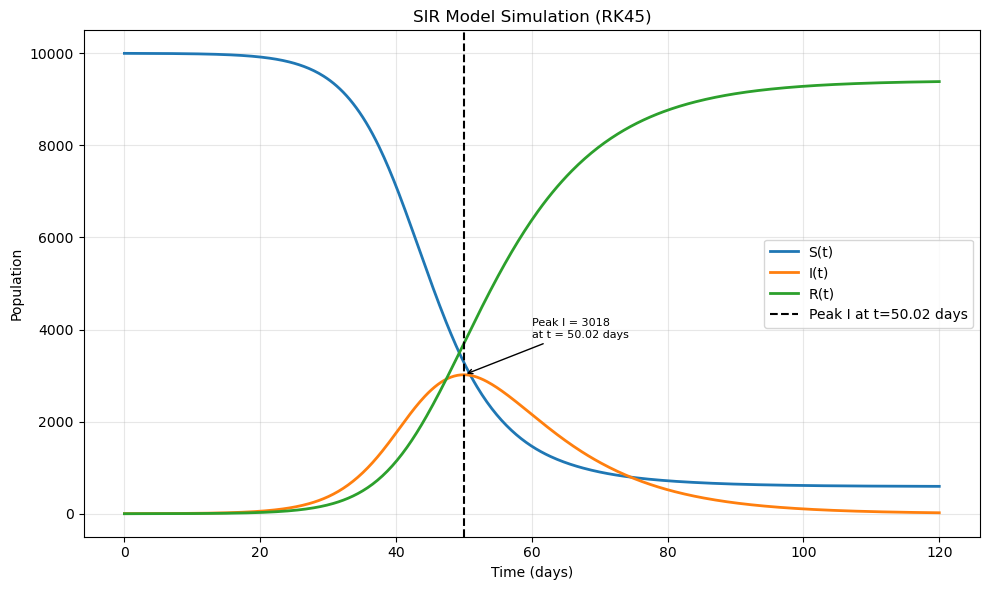

In [9]:
# Simulate SIR with true parameters and initial conditions using RK45
beta_true = beta
gamma_true = gamma
y0_true = y0

sol = solve_ivp(
    sir_model,
    t_span,
    y0_true,
    args=(beta_true, gamma_true),
    method="RK45",
    t_eval=t_eval,
)
S, I, R = sol.y

# Peak infection time and value
peak_i = np.argmax(I)
t_peak = t_eval[peak_i]
I_peak = I[peak_i]

plt.figure(figsize=(10, 6))
plt.plot(t_eval, S, label="S(t)", linewidth=2)
plt.plot(t_eval, I, label="I(t)", linewidth=2)
plt.plot(t_eval, R, label="R(t)", linewidth=2)

plt.axvline(t_peak, color="black", linestyle="--", linewidth=1.5, label=f"Peak I at t={t_peak:.2f} days")
# I asked the VS code model for the annotation code and it looked up the format for me, so I just copied it here.

plt.annotate(
    f"Peak I = {I_peak:.0f}\nat t = {t_peak:.2f} days",
    xy=(t_peak, I_peak),
    xytext=(t_peak + 10, I_peak + 0.08 * N),
    arrowprops=dict(arrowstyle="->"),
    fontsize=8,
)

plt.title("SIR Model Simulation (RK45)")
plt.xlabel("Time (days)")
plt.ylabel("Population")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Daily Incidence')

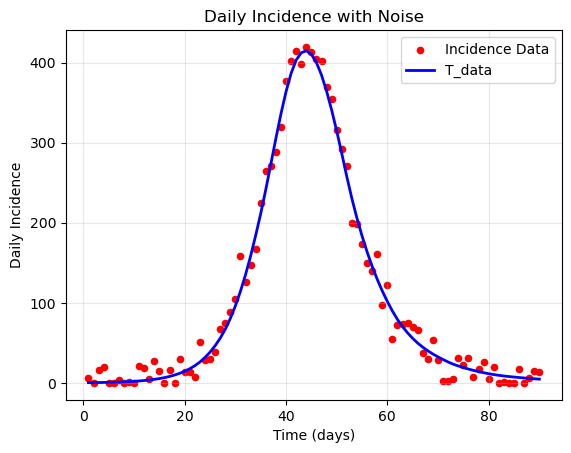

In [10]:
rng = np.random.default_rng(seed=42)
t_data = np.arange(0, 91, dtype=float)

sol_true = solve_ivp(
    sir_model,
    t_span,
    y0_true,
    args=(beta_true, gamma_true),
    t_eval=t_data,
    method="RK45",
)

# daily incidence: ds/dt = -beta * S * I

incidence_true = -np.diff(sol_true.y[0])  # -dS/dt
noise = rng.normal(0, 0.05 * incidence_true.max(), size=len(incidence_true))

incidence_data = np.clip(incidence_true + noise, 0, None)

plt.scatter(t_data[1:], incidence_data, label="Incidence Data", color="red", s=20)
plt.plot(t_data[1:], incidence_true, label="T_data", color="blue", linewidth=2)
plt.legend()
plt.grid(alpha=0.3)
plt.title("Daily Incidence with Noise")
plt.xlabel("Time (days)")
plt.ylabel("Daily Incidence")

In [11]:
def incidence_model(t, beta, gamma):
    t = np.asarray(t, dtype=float)
    t0 = float(np.min(t))
    t1 = float(np.max(t)) + 1.0

    eval_times = np.unique(np.concatenate([t, t + 1.0]))
    sol_fit = solve_ivp(
        sir_model,
        (t0, t1),
        y0_true,
        args=(beta, gamma),
        t_eval=eval_times,
        method="RK45",
    )

    s_values = dict(zip(sol_fit.t, sol_fit.y[0]))
    return np.array([s_values[time] - s_values[time + 1.0] for time in t])

# incidence_data[i] represents the change over [t_i, t_{i+1}], so fit at the interval starts
t_fit = t_data[:-1]

popt, _ = curve_fit(
    incidence_model,
    t_fit,
    incidence_data,
    p0=[beta_true, gamma_true],
    bounds=(0, np.inf),
    maxfev=20000,
)
beta_est, gamma_est = popt


print(f"Fitted beta:  {beta_est:.6e}  true beta:  {beta_true:.6e}")
print(f"Fitted gamma: {gamma_est:.6f}  true gamma: {gamma_true:.6f}")
print(f"Beta rel. error:  {100 * abs(beta_est - beta_true) / beta_true:.2f}%")
print(f"Gamma rel. error: {100 * abs(gamma_est - gamma_true) / gamma_true:.2f}%")

Fitted beta:  2.967983e-05  true beta:  3.000000e-05
Fitted gamma: 0.096113  true gamma: 0.100000
Beta rel. error:  1.07%
Gamma rel. error: 3.89%


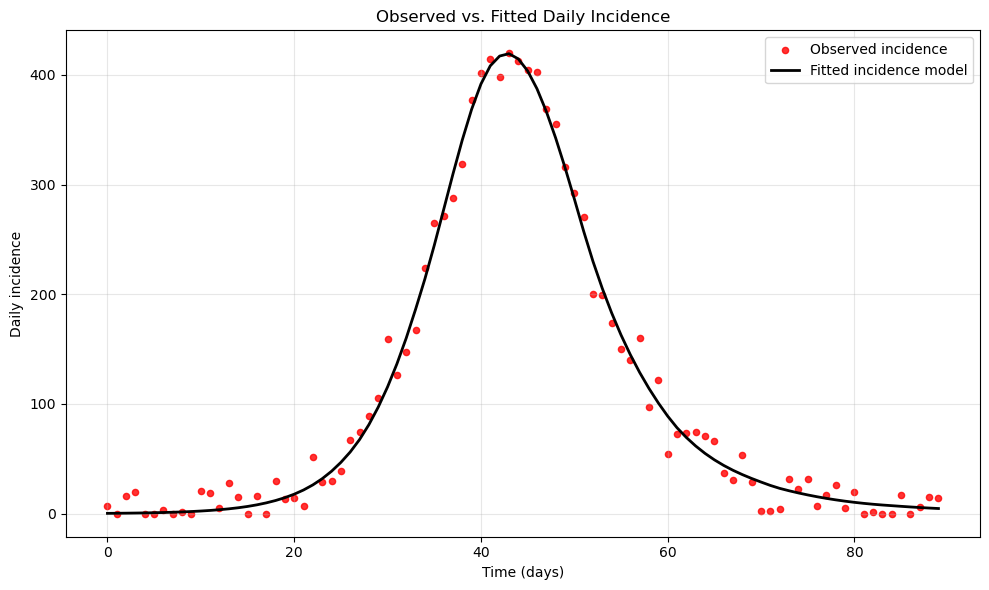

In [12]:
# Reconstruct the fitted incidence curve and compare it to the noisy data
fitted_incidence = incidence_model(t_fit, beta_est, gamma_est)

plt.figure(figsize=(10, 6))
plt.scatter(t_fit, incidence_data, label="Observed incidence", color="red", s=20, alpha=0.8)
plt.plot(t_fit, fitted_incidence, label="Fitted incidence model", color="black", linewidth=2)
plt.legend()
plt.grid(alpha=0.3)
plt.title("Observed vs. Fitted Daily Incidence")
plt.xlabel("Time (days)")
plt.ylabel("Daily incidence")
plt.tight_layout()
plt.show()

## Part (d)
Using the fitted parameters, the model reproduces the shape of the daily incidence curve very well. It shows the timing of the main peak and the peak magnitude is close, but not exact, because the added noise and incidence have some mismatch. The residuals appear random rather than strongly systematic, so the fitted SIR model is a good but not an amazing description of the data.